# 1. Exploratory Data Analysis (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Power Consumption Data**

The analysis utilizes the EVSE-B-PowerCombined.csv dataset, which comprises power consumption logs from an EVSE-B unit (based on Raspberry Pi 4 hardware) across various operational scenarios. Each sample is timestamped at a 1 Hz sampling frequency and includes annotated state and attack labels for classification.

### Feature Descriptions

| Feature              | Description |
|----------------------|---------------------------------------------------------------|
| Time                | Timestamp of sample |
| Shunt_voltage (mV)  | Voltage drop that occurs across a shunt resistor of I2C Wattmeter |
| Bus_voltage         | DC Voltage supply |
| Current_mA         | EVSE-B Current consumption |
| Power_mw           | EVSE-B Power consumption |

### Labelling

| Column ID  | Entry |
|------------|-----------------------------------------------------------------------------------------------|
| State      | Idle, Charging |
| Scenario   | Recon, DoS, Cryptojacking, Backdoor, Benign |
| Attack     | Cryptojacking, Backdoor, None (i.e., Benign), syn-stealth-scan (Recon), vulnerability-scan (Recon), tcp-flood (DoS), syn-flood (DoS) |
| Label      | Attack, Benign |
| Interface  | OCPP, ISO15118 |


In [7]:
DATA_PATH = 'data/EVSE-B-PowerCombined.csv'
data = pd.read_csv(DATA_PATH, delimiter=',')

In [9]:
data.head()

,time,shunt_voltage,bus_voltage_V,current_mA,power_mW,State,Attack,Attack-Group,Label,interface
0,12/25/2023 22:35,978,5.165,1027,5300,idle,syn-flood,DoS,attack,ocpp
1,12/25/2023 22:35,872,5.161,1009,4980,idle,syn-flood,DoS,attack,ocpp
2,12/25/2023 22:35,1017,5.165,1029,5300,idle,syn-flood,DoS,attack,ocpp
3,12/25/2023 22:35,930,5.161,1005,5180,idle,syn-flood,DoS,attack,ocpp
4,12/25/2023 22:35,958,5.165,1034,5180,idle,syn-flood,DoS,attack,ocpp


In [11]:
data.shape  # 115298 rows

(115298, 10)

In [13]:
print(data.isnull().sum())   # No missing values

time             0
shunt_voltage    0
bus_voltage_V    0
current_mA       0
power_mW         0
State            0
Attack           0
Attack-Group     0
Label            0
interface        0
dtype: int64


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115298 entries, 0 to 115297
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   time           115298 non-null  object 
 1   shunt_voltage  115298 non-null  int64  
 2   bus_voltage_V  115298 non-null  float64
 3   current_mA     115298 non-null  int64  
 4   power_mW       115298 non-null  int64  
 5   State          115298 non-null  object 
 6   Attack         115298 non-null  object 
 7   Attack-Group   115298 non-null  object 
 8   Label          115298 non-null  object 
 9   interface      115298 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 8.8+ MB


## Summary Statistics and histograms

In [18]:
data.describe()   

,shunt_voltage,bus_voltage_V,current_mA,power_mW
count,115298.000000,115298.000000,115298.000000,115298.000000
mean,619.787932,5.188204,619.760672,3212.783916
std,197.188339,0.014482,197.312950,1011.567259
min,417.000000,5.149000,417.000000,2160.000000
25%,467.000000,5.181000,467.000000,2420.000000
50%,510.000000,5.197000,510.000000,2660.000000
75%,746.000000,5.197000,747.000000,3860.000000
max,1214.000000,5.209000,1220.000000,6300.000000


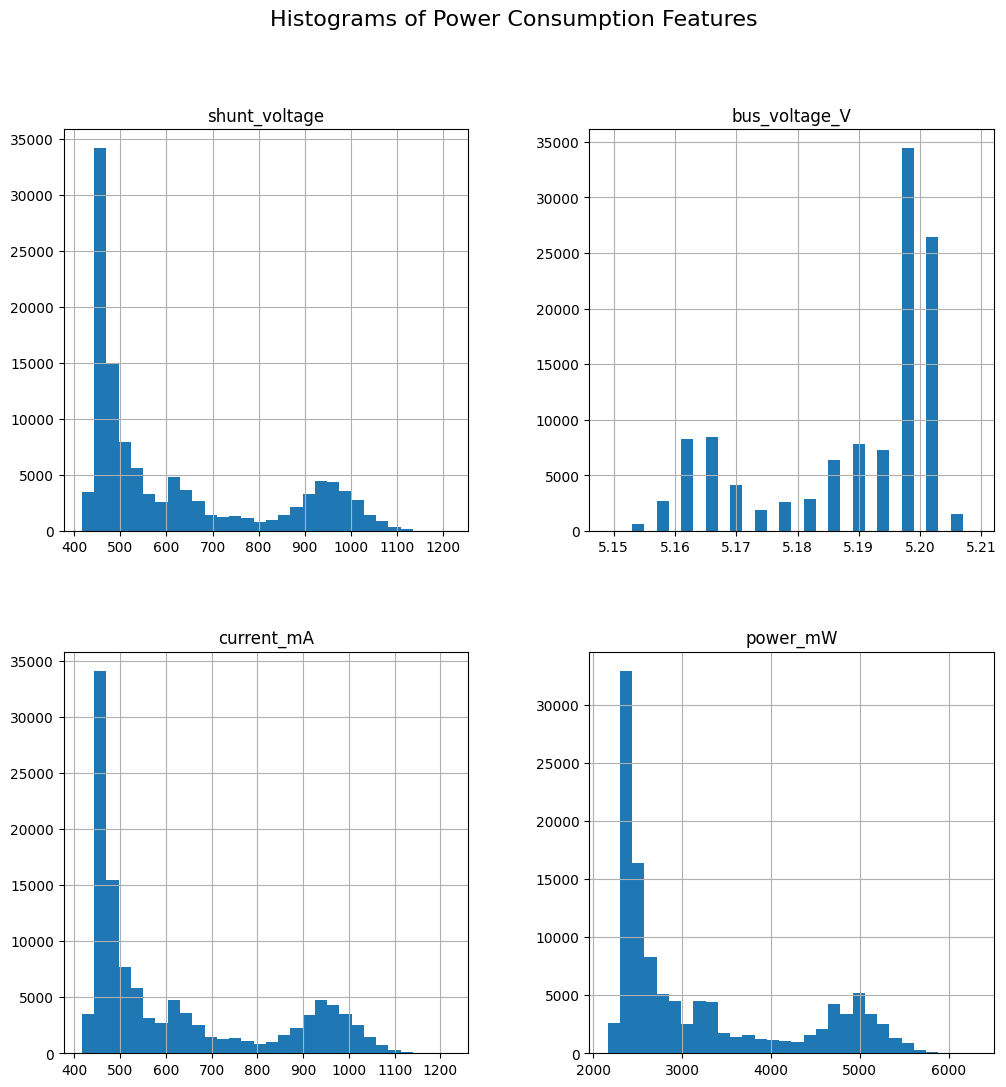

In [20]:
data.hist(bins=30, figsize=(12, 12))
plt.suptitle("Histograms of Power Consumption Features", fontsize=16)
plt.show()

**Initial Data Distribution Analysis**

Preliminary visualization of the power consumption features reveals distinct patterns:

Shunt Voltage & Current (mA): Both features exhibit a right-skewed distribution. The bimodal peak structure, centered approximately at 450 units and 950 units, suggests distinct operational modes corresponding to the device’s state transitions (e.g., idle vs. active).

Bus Voltage: The supply voltage remains highly stable, fluctuating within a narrow range (5.15V to 5.21V), indicating regulated DC power delivery throughout the experiment.

Power (mW): As a derivative metric of bus voltage and current, the power distribution mirrors the current consumption pattern, confirming that current variance is the primary driver of power consumption fluctuations.

*******

## Boxplots

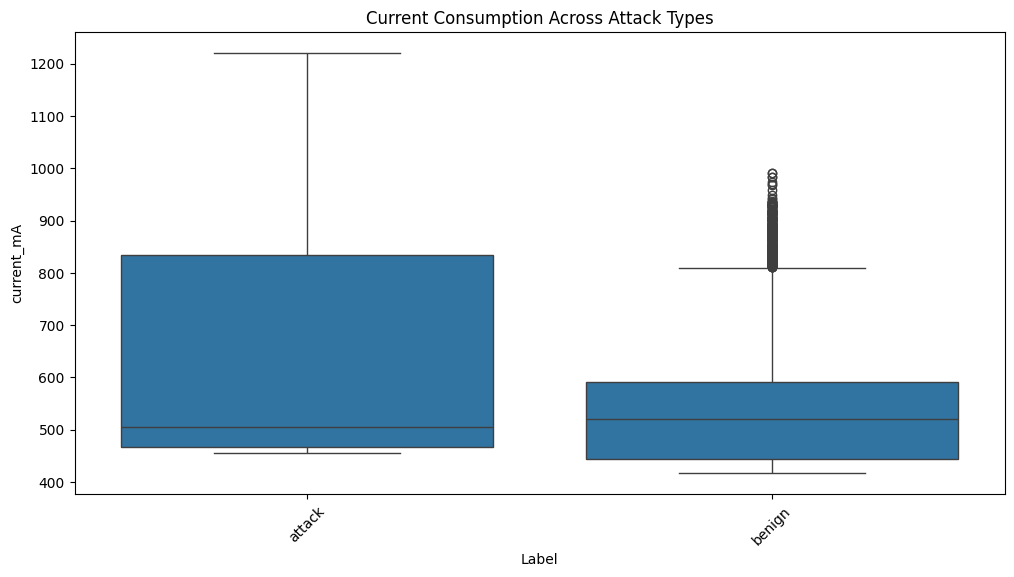

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x="Label", y="current_mA")
plt.xticks(rotation=45)
plt.title("Current Consumption Across Attack Types")
plt.show()

Right skewed as expected, more dispersed data for the attacks.

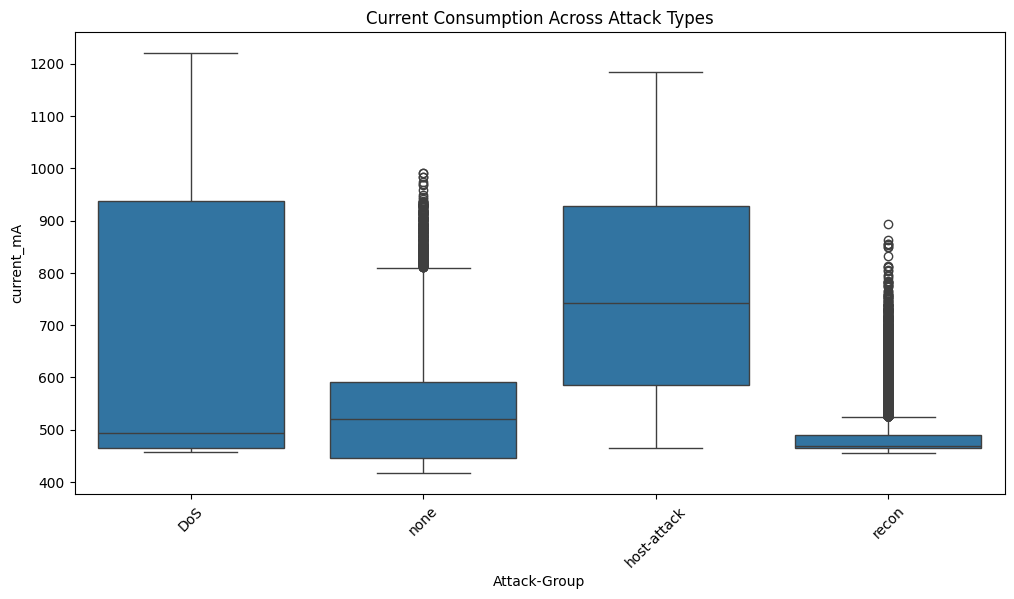

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x="Attack-Group", y="current_mA")
plt.xticks(rotation=45)
plt.title("Current Consumption Across Attack Types")
plt.show()

Recon similar with benign fall inside the range. DoS and host-attack (cryptojacking, backdoor) more dispersed and also indication of difference with the benign. 

*****

- High variability in current consumption during DoS attacks, indicating significant fluctuations in power.

- Benign state is more stable but slightly overlaps with DoS.

- Host attacks also exhibit high variance with a wider range of current consumption.

- Recon attacks have a very stable and a lower power consumption profile compared to other attack types. Benign and Recon attacks have overlapping distributions in terms of current consumption, so distinguishing between them based on this feature can be challenging.

******

In [34]:
data['Attack'].value_counts()

Attack
vuln-scan        26246
tcp-flood        21367
Backdoor         21137
none             14363
syn-flood        13517
cryptojacking    11596
syn-stealth       7072
Name: count, dtype: int64

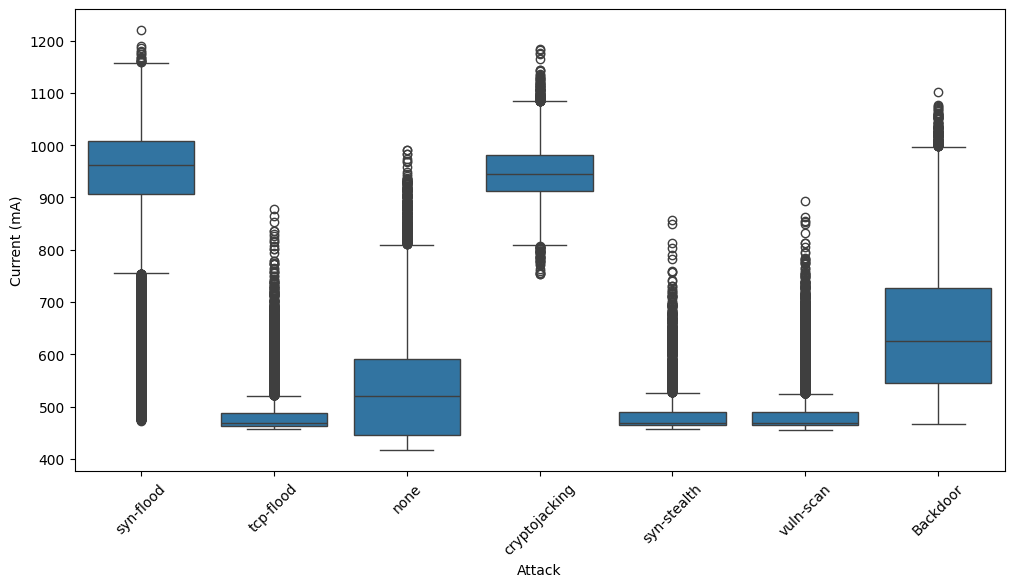

In [42]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x="Attack", y="current_mA")
plt.xticks(rotation=45)
plt.ylabel('Current (mA)')
plt.title("Current Consumption Across Attack Types")
plt.show()

In [48]:
summary = (
    data.groupby('Attack')['current_mA']
        .agg(
            Median='median',
            Q1=lambda x: x.quantile(0.25),
            Q3=lambda x: x.quantile(0.75),
            IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
        )
        .round(2)
)

print(summary)

               Median     Q1      Q3    IQR
Attack                                     
Backdoor        626.0  545.0   726.0  181.0
cryptojacking   945.0  912.0   981.0   69.0
none            520.0  445.0   591.0  146.0
syn-flood       963.0  906.0  1007.0  101.0
syn-stealth     469.0  465.0   490.0   25.0
tcp-flood       468.0  464.0   487.0   23.0
vuln-scan       468.0  465.0   489.0   24.0


In [50]:
data.groupby('Attack')['current_mA'].std()

Attack
Backdoor         130.729219
cryptojacking     52.790835
none              98.908252
syn-flood        134.248152
syn-stealth       46.142383
tcp-flood         43.059715
vuln-scan         44.824663
Name: current_mA, dtype: float64

******

- Syn-flood and Cryptojacking attacks exhibit the highest median current consumption (963 mA and 945 mA, respectively). Cryptojacking also shows a relatively compact distribution (IQR = 69 mA), indicating a consistent electrical signature that is well separated from benign activity and therefore easier to distinguish using power consumption features.

- TCP-flood, Syn-stealth, and Vulnerability Scan exhibit remarkably similar current distributions, with median currents of 468–469 mA and narrow interquartile ranges (23–25 mA). Their close overlap with the benign idle operating regime indicates that these attacks produce comparable electrical signatures. Furthermore, the DoS category contains both these low-current attacks and the high-current Syn-flood attack, resulting in substantial intra-class heterogeneity that is likely to reduce class separability during multiclass classification.

- Backdoor attacks exhibit the largest spread (IQR = 181 mA), reflecting considerable variability in their electrical behavior. Although their median current (626 mA) is higher than benign activity, the broad distribution results in overlap with both benign and other attack categories, suggesting that additional features or temporal information may improve discrimination.

- The Benign category exhibits substantial variability, reflecting differences between idle and charging operation. This overlap with certain low-power attacks (e.g., TCP-flood, Syn-stealth, Vulnerability Scan) is consistent with the elevated false-positive rates observed during classification and highlights the limitations of relying solely on instantaneous power measurements.

## Benign class current distribution by operational state (full dataset)

In [44]:
print('State values:', data['State'].unique())
print('Label values:', data['Label'].unique())
print()
print(data[['State', 'Label']].value_counts())

State values: ['idle' 'charging']
Label values: ['attack' 'benign']

State     Label 
idle      attack    78289
charging  attack    22646
idle      benign     7416
charging  benign     6947
Name: count, dtype: int64


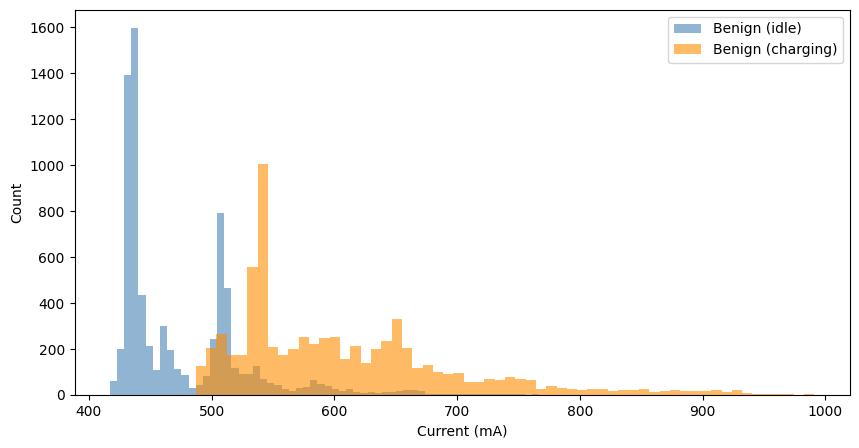

In [46]:
benign = data[data['Label'] == 'benign']

plt.figure(figsize = (10, 5))
for state, color in [('idle', 'steelblue'), ('charging', 'darkorange')]:
    subset = benign[benign['State'] == state]
    plt.hist(subset['current_mA'], bins = 60, alpha = 0.6, label = f'Benign ({state})', color = color)
plt.xlabel('Current (mA)')
plt.ylabel('Count')
plt.legend()
#plt.title('Benign class current distribution by operational state')
plt.savefig('benign_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**Composition of the inter-mode band (investigate what lies between the two benign regimes)**

In [65]:
band = data[(data['current_mA'] > 480) & (data['current_mA'] < 580)]

print('By label:')
print(band['Label'].value_counts(normalize = True).round(3))
print()
print('By attack group:')
print(band['Attack-Group'].value_counts(normalize = True).round(3))
print()
print(f'Band size: {len(band)} samples ({len(band)/len(data)*100:.1f}% of dataset)')

By label:
Label
attack    0.763
benign    0.237
Name: proportion, dtype: float64

By attack group:
Attack-Group
recon          0.307
host-attack    0.241
none           0.237
DoS            0.215
Name: proportion, dtype: float64

Band size: 23943 samples (20.8% of dataset)


The benign class exhibits a clear bimodal distribution corresponding to the EVSE operational state. Idle samples are concentrated around 430–490 mA, whereas charging samples peak around 540 mA while occupying a substantially broader range extending beyond 900 mA. An intermediate transition region (approximately 480–580 mA) contains approximately 21% of all observations and is dominated by attack traffic (76%), particularly reconnaissance and host-based attacks. This overlap suggests that operational state introduces substantial variability in power consumption, reducing class separability when idle and charging samples are analysed jointly. It also has consequences for interpolation-based oversampling: synthetic benign samples generated between the two modes fall predominantly within this attack-dominated region.

******

## Statistical Analysis of Attack vs benign

To quantify the difference in current consumption between attack and benign states, we performed an independent Welch's t-test (as the assumption of equal variance was not met). The test yielded a highly significant difference ($p < 0.001$). Given the substantial sample size ($N=115,298$), we complemented the p-value with the effect size using Cohen's $d$. The calculated effect size of $d \approx 0.476$ indicates a medium effect, confirming that the observed disparity in electrical behavior between attack vectors and benign states is statistically significant and practically meaningful for anomaly detection purposes.

In [56]:
data.groupby("Label")["current_mA"].describe()  # compare current value for attack - benign

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
attack,100935.0,631.318987,204.958711,456.0,467.0,506.0,834.0,1220.0
benign,14363.0,538.535403,98.908252,417.0,445.0,520.0,591.0,991.0


**Welch's t-test**

We perform an independent t-test (Welch’s t-test since equal_var=False) which checks whether the means of two independent groups are significantly different. 
- Null Hypothesis (H₀): The mean current_mA is the same for attack and benign data.
- Alternative Hypothesis (H₁): The mean current_mA is different between the two groups.

In [60]:
from scipy.stats import ttest_ind

attack_current = data[data["Label"] == "attack"]["current_mA"]
benign_current = data[data["Label"] == "benign"]["current_mA"]

t_stat, p_value = ttest_ind(attack_current, benign_current, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 88.57430701201648, P-value: 0.0


p-value < 0.05, thus there is a highly significant difference in current consumption between attack and benign states.

**Cohen's d**

In [64]:
# Calculate Cohen's d for effect size
n1, n2 = len(attack_current), len(benign_current)
s1, s2 = np.var(attack_current, ddof=1), np.var(benign_current, ddof=1)
s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
cohens_d = (np.mean(attack_current) - np.mean(benign_current)) / s_pooled

print(f"Cohen's d: {cohens_d:.4f}")

Cohen's d: 0.4760


The calculated effect size indicates a medium effect.

## Class distribution

We see that there is class inbalance which we have to keep in mind.

In [69]:
print(data["Attack"].value_counts())

Attack
vuln-scan        26246
tcp-flood        21367
Backdoor         21137
none             14363
syn-flood        13517
cryptojacking    11596
syn-stealth       7072
Name: count, dtype: int64


In [71]:
print(data["Label"].value_counts())

Label
attack    100935
benign     14363
Name: count, dtype: int64


In [73]:
print(data["Attack-Group"].value_counts())

Attack-Group
DoS            34884
recon          33318
host-attack    32733
none           14363
Name: count, dtype: int64


We split the data in 5 different datasets df_benign, df_recon, df_Backdoor, df_cryptojacking, df_Dos

In [76]:
df_recon=data[data["Attack-Group"]=='recon']
df_DoS=data[data["Attack-Group"]=='DoS']
df_benign=data[data["Label"]=='benign']
df_Backdoor=data[data["Attack"]=='Backdoor']
df_cryptojacking=data[data["Attack"]=='cryptojacking']

In [78]:
df_Backdoor.shape[0],df_benign.shape[0],df_recon.shape[0],df_cryptojacking.shape[0],df_DoS.shape[0]

(21137, 14363, 33318, 11596, 34884)

## Correlation analysis

In [81]:
corr_matrix = data.corr(numeric_only=True)

In [83]:
corr_matrix["current_mA"].sort_values(ascending=False)

current_mA       1.000000
power_mW         0.963770
shunt_voltage    0.935458
bus_voltage_V   -0.947728
Name: current_mA, dtype: float64

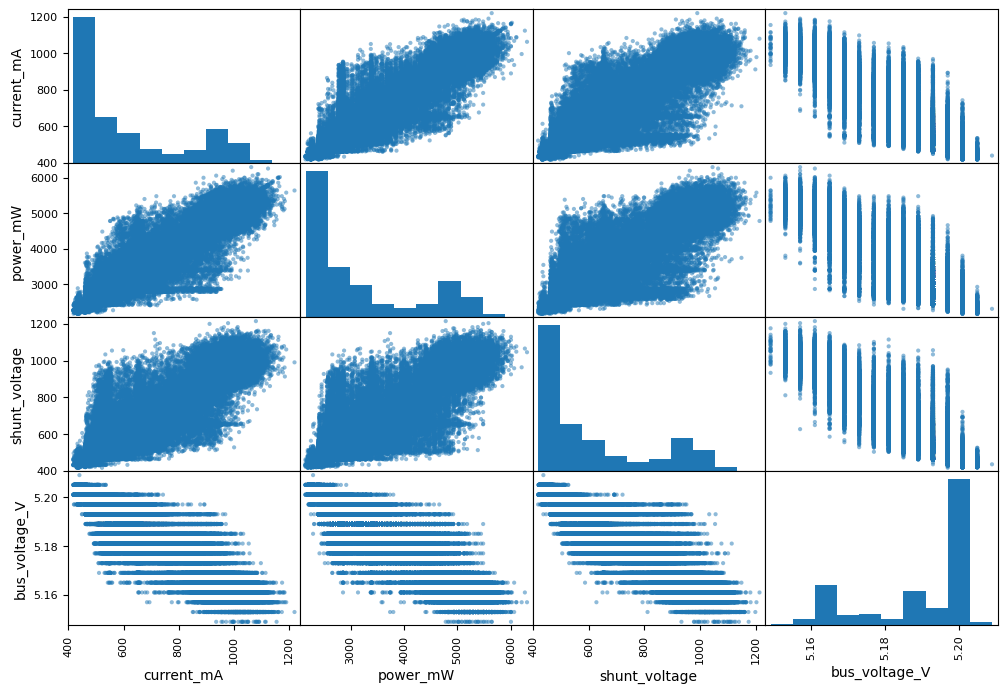

In [85]:
from pandas.plotting import scatter_matrix

attributes = ["current_mA", "power_mW", "shunt_voltage","bus_voltage_V"]
scatter_matrix(data[attributes], figsize=(12, 8))
# save_fig("scatter_matrix_plot")  # extra code
plt.show()

We see a strong negative correlation with current and bus_voltage which is not expected due to Ohm law ($I=\frac{V}{R}$). However this might be the case in circuits. The bus voltage is typically the total system voltage before the shunt resistor and the shunt voltage is the small voltage drop across a resistor that is used to measure current. Since the shunt voltage increases with current, it should be positively correlated but if the power source has internal resistance, an increase in current can cause a voltage drop in the system. Also we see a strong positive correlation between power and current which is also expected since bus_voltage is almost stable and power is calculated by the formula $P=V\times I$. While these features are mathematically redundant, both were retained during the Exploratory Data Analysis and subsequent PCA to ensure that the cumulative variance of the electrical signal is fully captured for unsupervised clustering.

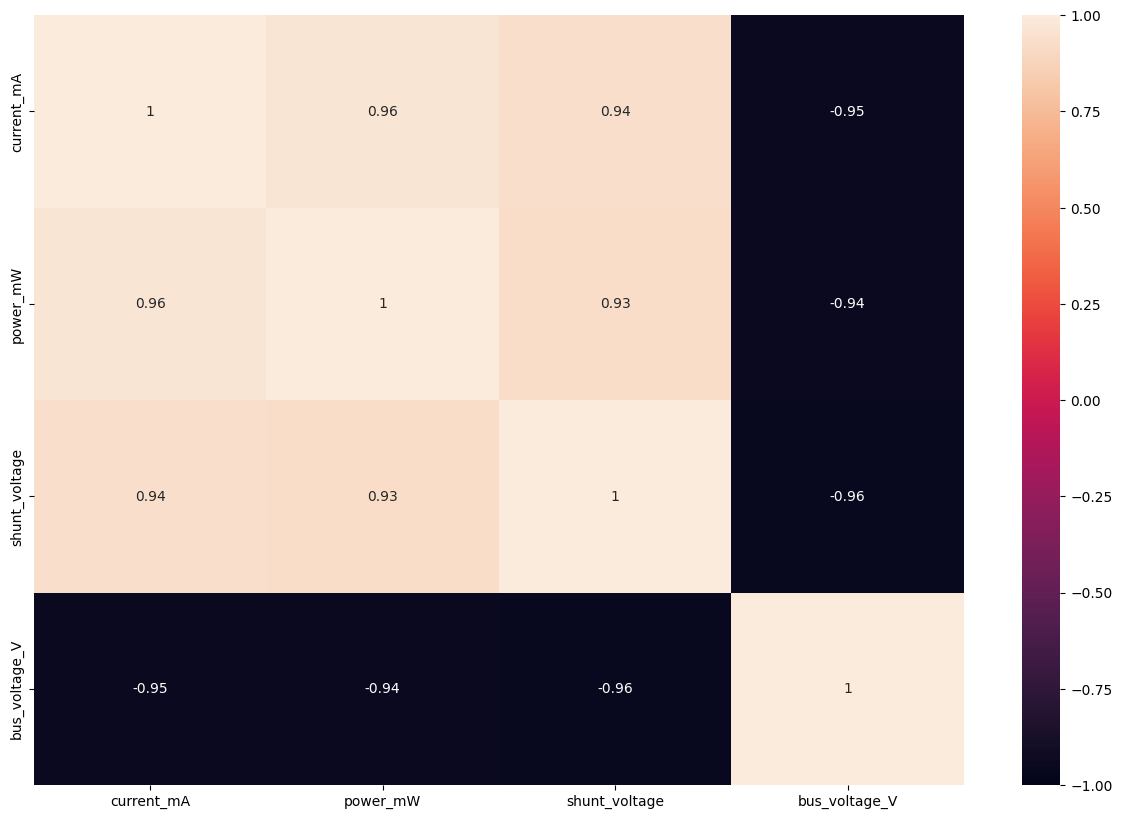

In [88]:
fig = plt.figure(figsize = (15,10))
sns.heatmap(data[attributes].corr(), vmin = -1, vmax = 1, annot = True)
plt.show()

## Wattmeter current readings (moving average, window size=20) across different attacks.

The first plot is calculating the simple moving average of the current_mA values using a rolling window of size 20. Each point in df['current_mA_ma'] will be the average of the previous 20 current_mA values.

The Simple Moving Average is the most basic type, where each data point in the resulting series is the average of a fixed number of previous data points. It helps to smooth out short-term fluctuations and highlight longer-term trends (in our case current readings and the MA helps to filter out high-frequency noise). This is a visualization choice and the smoothing is not applied to the raw data used for training or feature engineering; the supervised models utilize the original 1 Hz sampled data.

C:\Users\klaza\AppData\Local\Temp\ipykernel_4092\3780971025.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'current_mA_ma'] = df['current_mA'].rolling(window=20).mean()  # The first 20 values will be NaN since we don't have enough values
C:\Users\klaza\AppData\Local\Temp\ipykernel_4092\3780971025.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'current_mA_ma'] = df['current_mA'].rolling(window=20).mean()  # The first 20 values will be NaN since we don't have enough values
C:\U

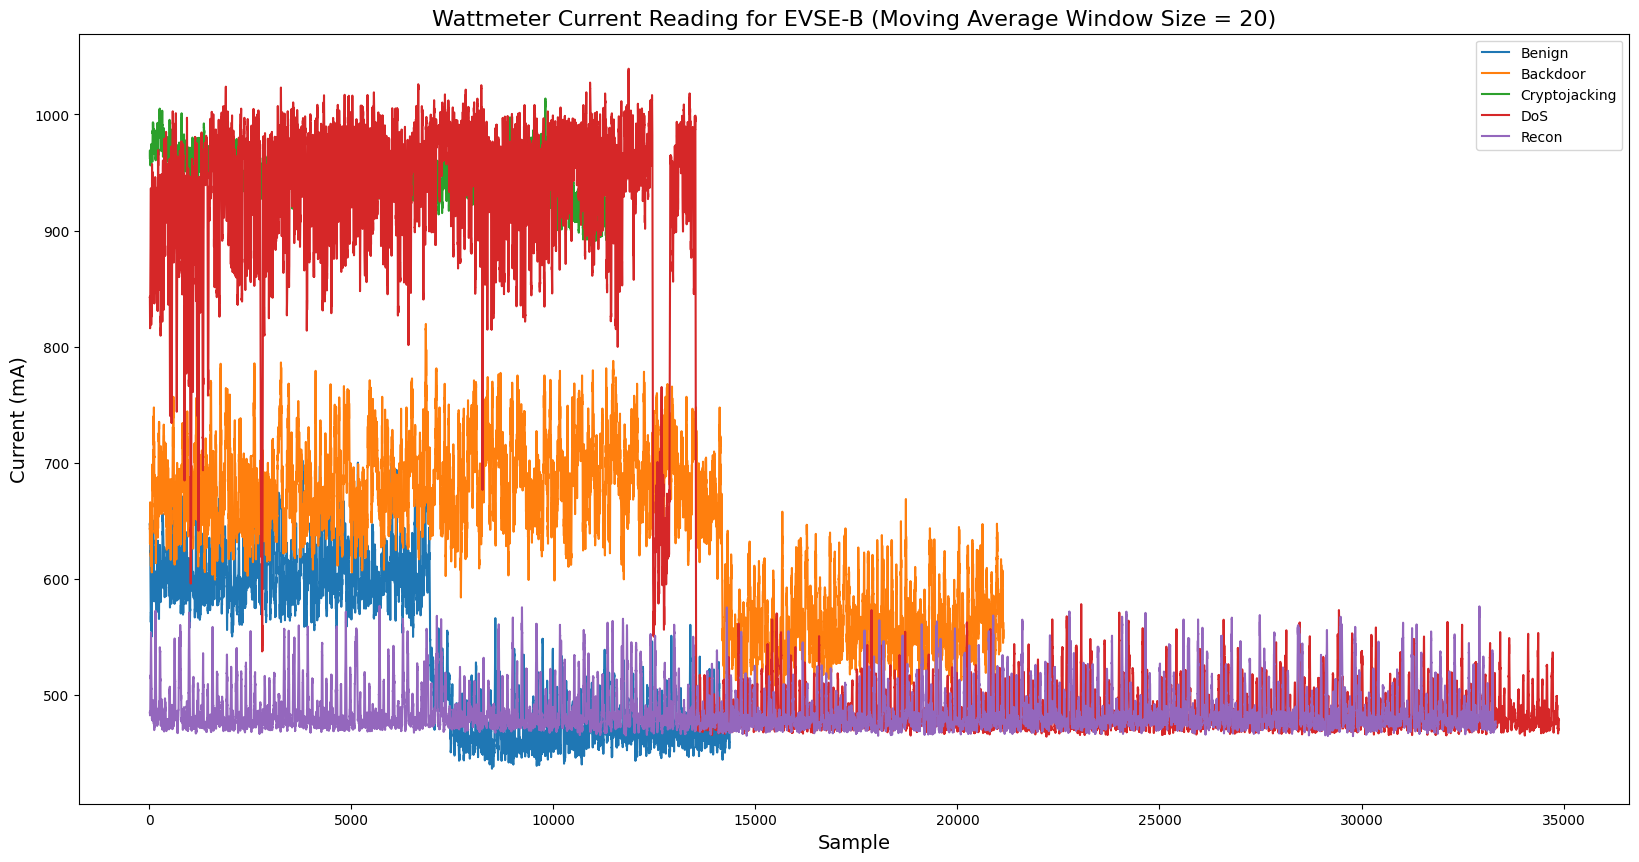

In [93]:
# List of dataframes
dataframes = [df_benign, df_Backdoor, df_cryptojacking, df_DoS, df_recon]
labels = ['Benign', 'Backdoor', 'Cryptojacking', 'DoS', 'Recon']

# Wattmeter Current Reading with moving average
plt.figure(figsize=(20, 10))

# Loop through dataframes and plot the moving average of current_mA
for df, label in zip(dataframes, labels):
    # Calculate moving average with window size = 20 and set it using .loc
    df.loc[:, 'current_mA_ma'] = df['current_mA'].rolling(window=20).mean()  # The first 20 values will be NaN since we don't have enough values 
                                                                                   # to calculate the moving average
    # Plot the moving average
    plt.plot(range(1, len(df) + 1), df['current_mA_ma'], label=label)

# plt.xlim(7000, 8000)

plt.title('Wattmeter Current Reading for EVSE-B (Moving Average Window Size = 20)', fontsize=16)
plt.xlabel('Sample', fontsize=14)  # Label as 'Sample'
plt.ylabel('Current (mA)', fontsize=14)
plt.legend()
plt.show()

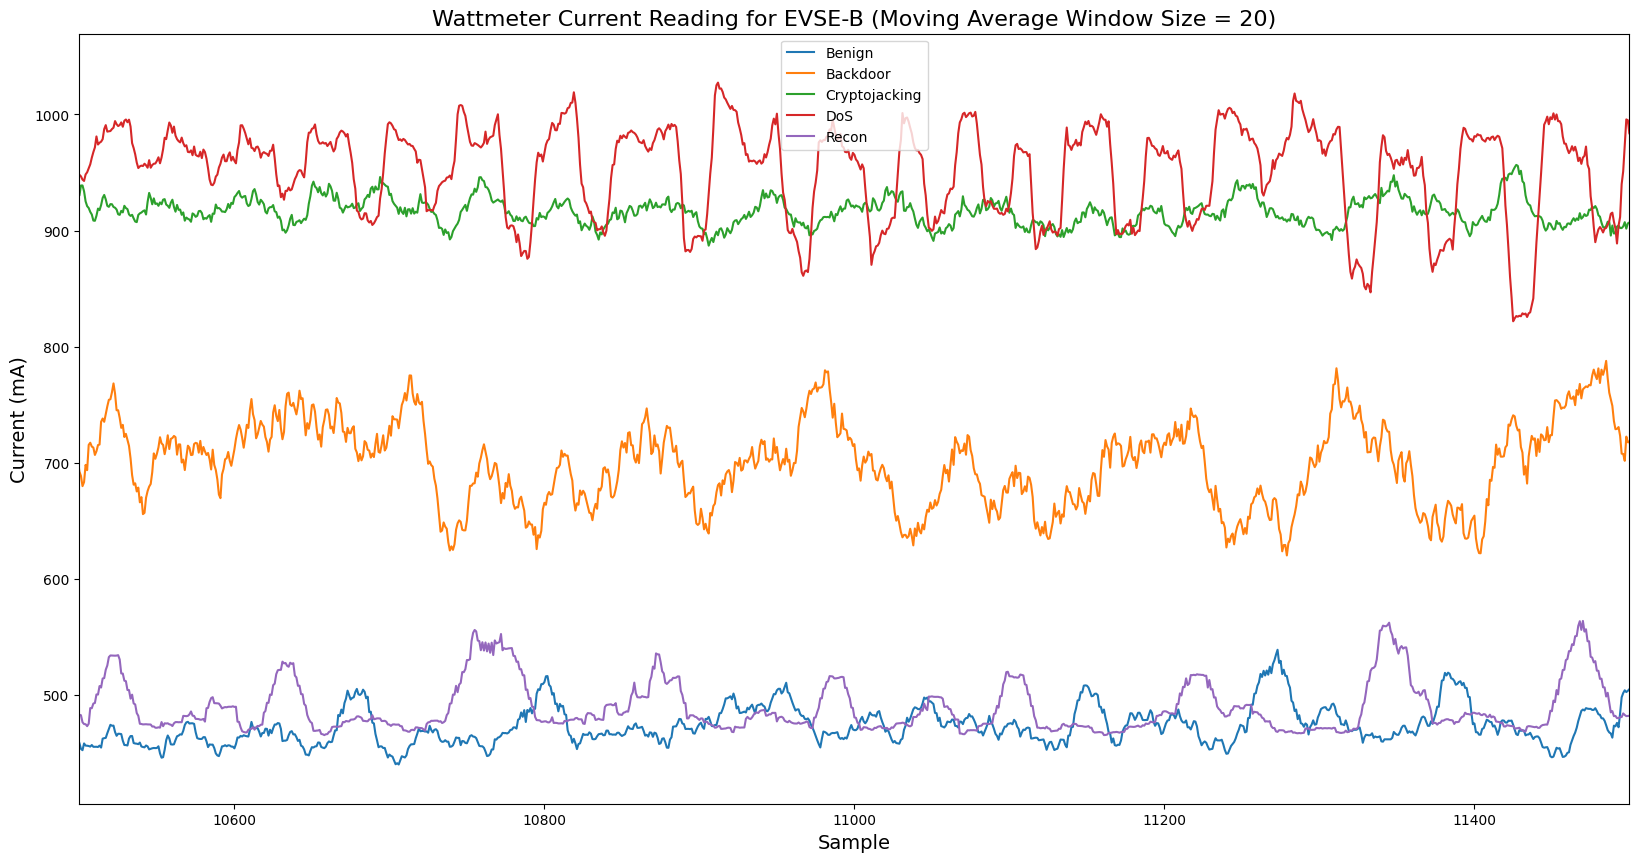

In [95]:
plt.figure(figsize=(20, 10))

# Loop through dataframes and plot the moving average of current_mA
for df, label in zip(dataframes, labels):
    # Calculate moving average with window size = 20 and set it using .loc
    df.loc[:, 'current_mA_ma'] = df['current_mA'].rolling(window=20).mean()
    
    # Plot the moving average
    plt.plot(range(1, len(df) + 1), df['current_mA_ma'], label=label)

plt.xlim(10500, 11500)

plt.title('Wattmeter Current Reading for EVSE-B (Moving Average Window Size = 20)', fontsize=16)
plt.xlabel('Sample', fontsize=14)  # Label as 'Sample'
plt.ylabel('Current (mA)', fontsize=14)
plt.legend()
plt.show()

## Percentage deviation of attacks from benign samples

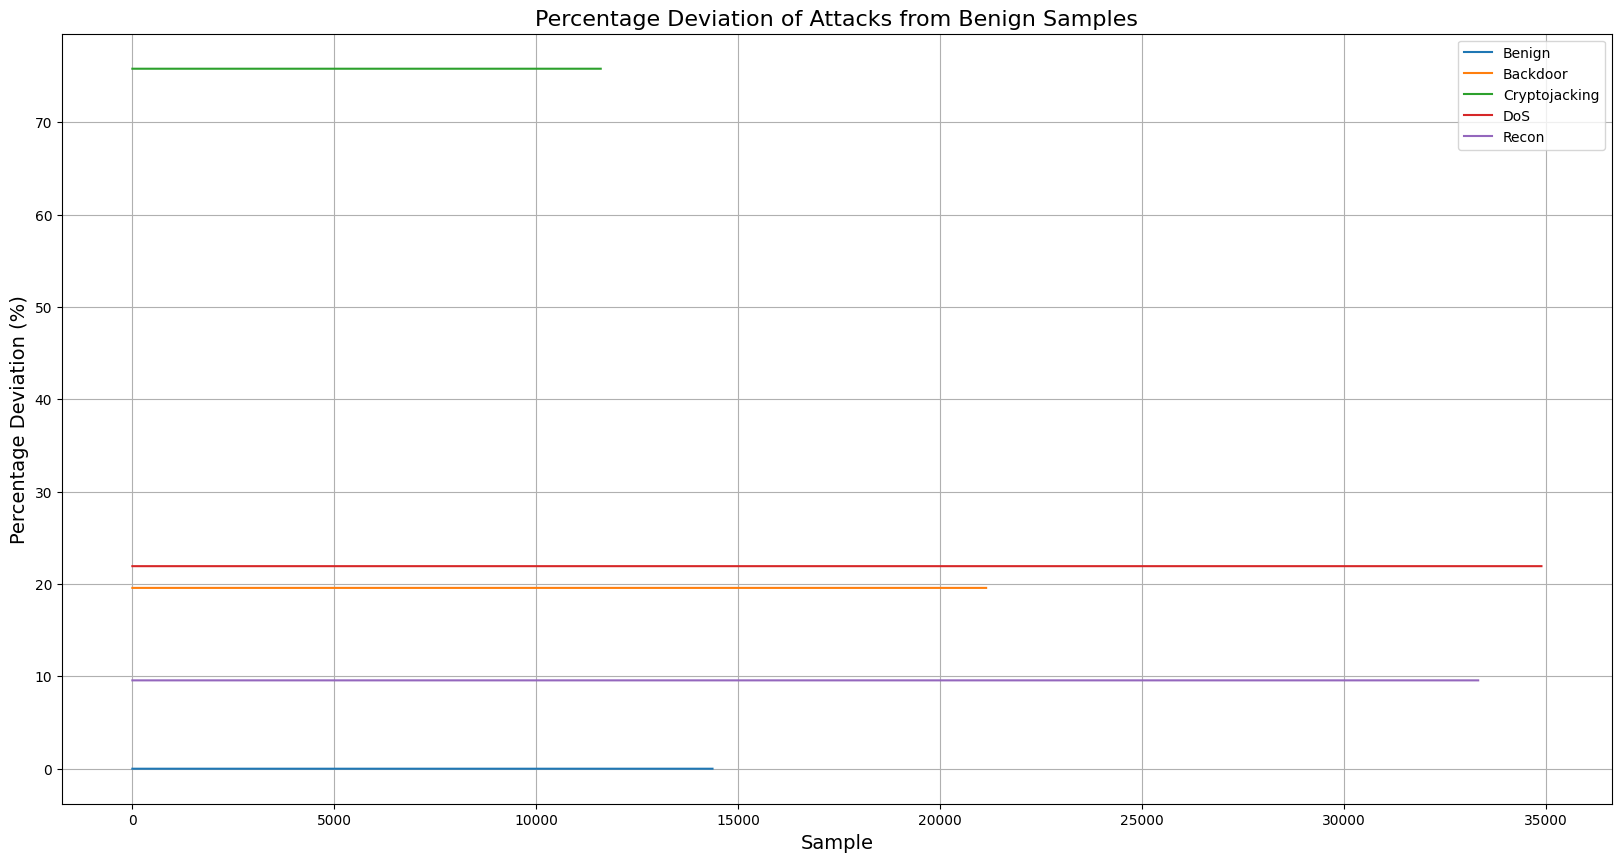

In [110]:
# Mean current_mA value for Benign (baseline)
benign_mean = df_benign['current_mA'].mean()

# Plot Percentage deviation of attacks from benign samples
plt.figure(figsize=(20, 10))

# Loop through dataframes and calculate percentage deviation
for df, label in zip(dataframes, labels):

#    if label.lower() in ['benign', 'none']:
#        continue
    
    # Calculate the mean current_mA value for the attack type
    attack_mean = df['current_mA'].mean()
    
    # Calculate the percentage deviation from the benign mean
    percentage_deviation = abs(attack_mean - benign_mean) / benign_mean * 100
    
    # Plot the percentage deviation (constant value for each sample)
    plt.plot(range(1, len(df) + 1), [percentage_deviation] * len(df), label=label)

plt.title('Percentage Deviation of Attacks from Benign Samples', fontsize=16)
plt.xlabel('Sample', fontsize=14)
plt.ylabel('Percentage Deviation (%)', fontsize=14)
plt.legend()
plt.grid()
plt.show()


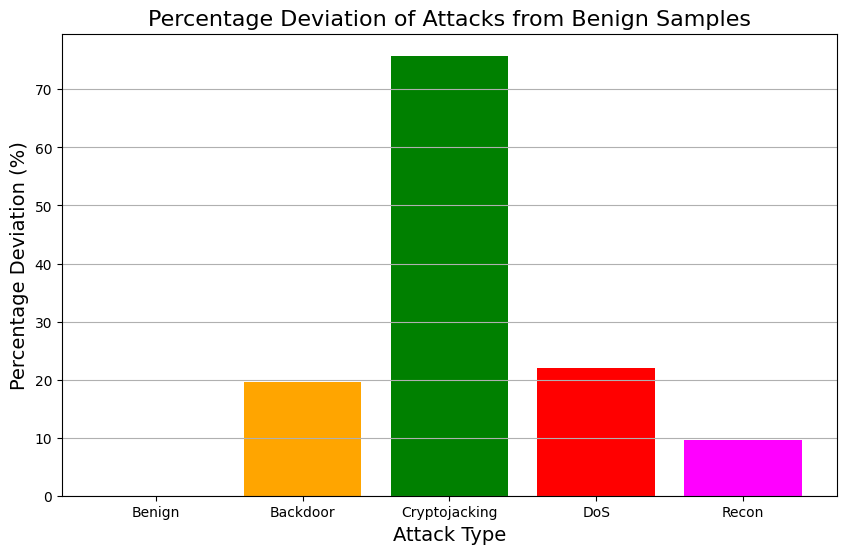

In [112]:
# Mean current_mA value for Benign (baseline)
benign_mean = df_benign['current_mA'].mean()

# Calculate percentage deviation for each attack type
deviations = []
for df, label in zip(dataframes, labels):

    # Calculate the mean current_mA value for the attack type
    attack_mean = df['current_mA'].mean()
    
    # Calculate the percentage deviation from the benign mean
    percentage_deviation = abs(attack_mean - benign_mean) / benign_mean * 100        
    deviations.append(percentage_deviation)

# Plot Bar plot for Percentage Deviation of Attacks from Benign Samples
plt.figure(figsize=(10, 6))

# Create bar plot
plt.bar(labels, deviations, color=['blue','orange','green','red','magenta'])

plt.title('Percentage Deviation of Attacks from Benign Samples', fontsize=16)
plt.xlabel('Attack Type', fontsize=14)
plt.ylabel('Percentage Deviation (%)', fontsize=14)
plt.grid(axis='y')
plt.show()


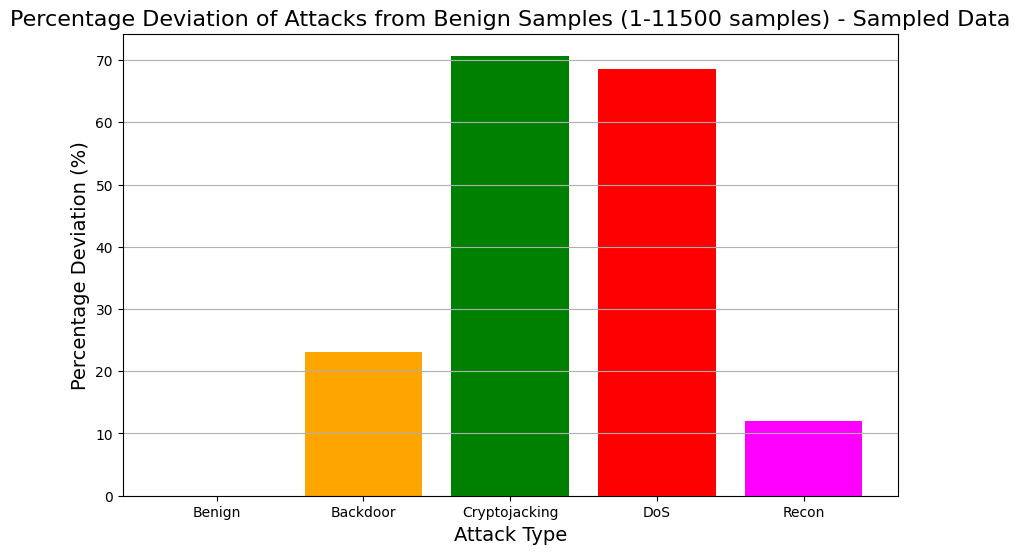

In [114]:
# Subset the data up to sample 11500 (index 0 to 11500)
df_benign_sampled = df_benign.iloc[:11500]
df_Backdoor_sampled = df_Backdoor.iloc[:11500]
df_cryptojacking_sampled = df_cryptojacking.iloc[:11500]
df_DoS_sampled = df_DoS.iloc[:11500]
df_recon_sampled = df_recon.iloc[:11500]

# List of sampled dataframes
dataframes_sampled = [df_benign_sampled, df_Backdoor_sampled, df_cryptojacking_sampled, df_DoS_sampled, df_recon_sampled]
labels = ['Benign', 'Backdoor', 'Cryptojacking', 'DoS', 'Recon']

# Mean current_mA value for Benign (baseline)
benign_mean_sampled = df_benign_sampled['current_mA'].mean()

# Calculate percentage deviation for each attack type in the sampled data
deviations_sampled = []
for df, label in zip(dataframes_sampled, labels):
    # Calculate the mean current_mA value for the attack type
    attack_mean_sampled = df['current_mA'].mean()
    
    # Calculate the percentage deviation from the benign mean
    percentage_deviation_sampled = abs(attack_mean_sampled - benign_mean_sampled) / benign_mean_sampled * 100
    deviations_sampled.append(percentage_deviation_sampled)


# Plot - Bar plot for Percentage Deviation of Attacks from Benign Samples (sampled data)
plt.figure(figsize=(10, 6))

# Create bar plot with different colors
plt.bar(labels, deviations_sampled, color=['blue','orange','green','red','magenta'])

plt.title('Percentage Deviation of Attacks from Benign Samples (1-11500 samples) - Sampled Data', fontsize=16)
plt.xlabel('Attack Type', fontsize=14)
plt.ylabel('Percentage Deviation (%)', fontsize=14)
plt.grid(axis='y')
plt.show()


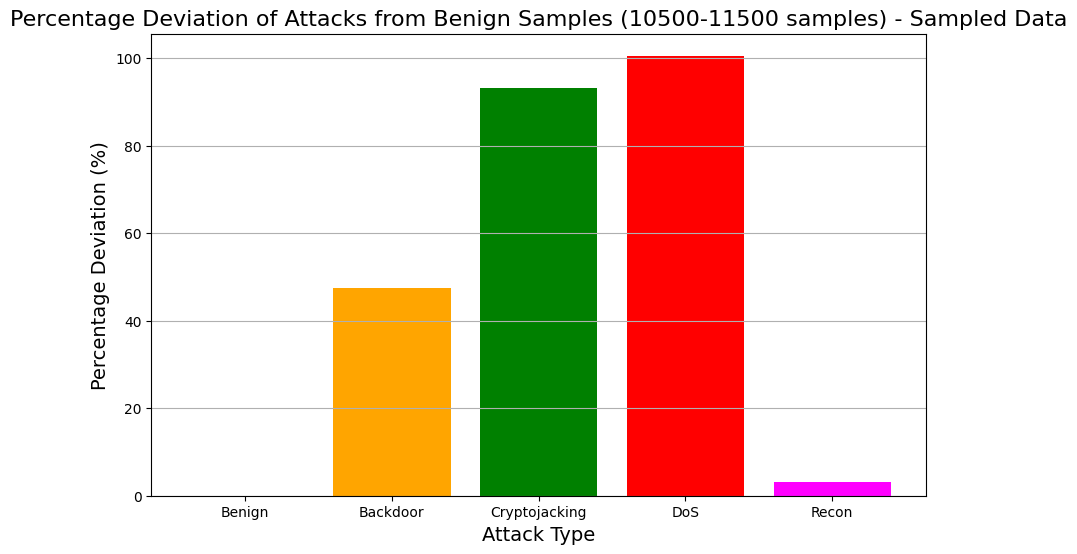

In [116]:
# Subset the data from sample 10500 to sample 11500 (index 10500 to 11500)
df_benign_sampled = df_benign.iloc[10500:11500]
df_Backdoor_sampled = df_Backdoor.iloc[10500:11500]
df_cryptojacking_sampled = df_cryptojacking.iloc[10500:11500]
df_DoS_sampled = df_DoS.iloc[10500:11500]
df_recon_sampled = df_recon.iloc[10500:11500]

# List of sampled dataframes
dataframes_sampled = [df_benign_sampled, df_Backdoor_sampled, df_cryptojacking_sampled, df_DoS_sampled, df_recon_sampled]
labels = ['Benign', 'Backdoor', 'Cryptojacking', 'DoS', 'Recon']

# Mean current_mA value for Benign (baseline)
benign_mean_sampled = df_benign_sampled['current_mA'].mean()

# Calculate percentage deviation for each attack type in the sampled data
deviations_sampled = []
for df, label in zip(dataframes_sampled, labels):
    # Calculate the mean current_mA value for the attack type
    attack_mean_sampled = df['current_mA'].mean()
    
    # Calculate the percentage deviation from the benign mean
    percentage_deviation_sampled = abs(attack_mean_sampled - benign_mean_sampled) / benign_mean_sampled * 100
    deviations_sampled.append(percentage_deviation_sampled)


# Plot - Bar plot for Percentage Deviation of Attacks from Benign Samples (sampled data)
plt.figure(figsize=(10, 6))

# Create bar plot with different colors
plt.bar(labels, deviations_sampled, color=['blue','orange','green','red','magenta'])

plt.title('Percentage Deviation of Attacks from Benign Samples (10500-11500 samples) - Sampled Data', fontsize=16)
plt.xlabel('Attack Type', fontsize=14)
plt.ylabel('Percentage Deviation (%)', fontsize=14)
plt.grid(axis='y')
plt.show()